# AICE Associate 대비 실습 과정 — 6회차
## 지도학습 II: 의사결정나무, 앙상블, 랜덤포레스트, 그라디언트부스팅

> **과정 구성**: 총 8회 × 3시간, 실습 위주  
> **선수 학습**: 1~5회차. 5회차의 선형회귀(R² 약 0.67)·로지스틱 회귀(정확도 약 0.80)를 **기준선(baseline)** 으로 두고, 트리 계열 모델이 얼마나 나아지는지 비교합니다.  
> **데이터**: 분류 = **타이타닉** 생존 예측, 회귀 = **캘리포니아 주택** 가격 예측

### 전체 커리큘럼

| 회차 | 주제 | 핵심 키워드 |
|:---:|------|------------|
| 1 | AI/ML/DL 개요, 데이터 획득하기 | AI ⊃ ML ⊃ DL, 지도/비지도, `read_csv`, `read_excel`, `to_csv` |
| 2 | 데이터 구조 확인하기, 기초 데이터 다루기 | `info`, `describe`, `loc/iloc`, 필터링, 정렬, `groupby`, `merge` |
| 3 | 데이터 이해하기 (EDA) | 분포, 상관관계, `matplotlib`, `seaborn`, 가설 검증 |
| 4 | 데이터 전처리하기 | 결측치, 이상치, 구간화, 인코딩, 스케일링, `train_test_split` |
| 5 | AI 모델링 필수 개념, 지도학습 I | 과적합, 평가지표, 선형회귀, 로지스틱 회귀 |
| **6** | **지도학습 II** | 의사결정나무, 앙상블, 랜덤포레스트, 그라디언트부스팅 |
| 7 | 인공신경망, 심층신경망, 딥러닝 프레임워크 | 퍼셉트론, 활성화함수, Keras `Sequential`, `EarlyStopping` |
| 8 | 비지도학습, 모델 성능 향상시키기 | K-Means, PCA, 교차검증, 하이퍼파라미터 튜닝, 모의고사 |

### 오늘의 학습 목표

1. 의사결정나무가 질문을 반복해 데이터를 나누는 원리(지니 불순도)를 설명할 수 있다.
2. `max_depth` 등 하이퍼파라미터로 트리의 과적합을 조절하고, 트리를 그림·텍스트로 해석할 수 있다.
3. 앙상블의 세 방식(보팅, 배깅, 부스팅)의 차이를 설명할 수 있다.
4. 랜덤포레스트와 그라디언트부스팅을 분류·회귀에 모두 적용하고 주요 하이퍼파라미터를 조정할 수 있다.
5. `feature_importances_` 로 변수 중요도를 해석할 수 있다.
6. 여러 모델을 같은 데이터·같은 지표로 공정하게 비교하는 표를 만들 수 있다.

### 시간 계획 (180분)

| 시간 | 내용 |
|------|------|
| 00:00 ~ 00:10 | 0. 환경 준비, 데이터·기준선 준비 |
| 00:10 ~ 00:55 | 1. 의사결정나무 |
| 00:55 ~ 01:05 | 휴식 |
| 01:05 ~ 01:20 | 2. 앙상블 개념 (보팅, 배깅, 부스팅) |
| 01:20 ~ 01:50 | 3. 랜덤포레스트 |
| 01:50 ~ 02:00 | 휴식 |
| 02:00 ~ 02:30 | 4. 그라디언트부스팅 (+ XGBoost) |
| 02:30 ~ 03:00 | 5. 모델 비교, 6. 종합 실습, 정리 |

---
## 0. 환경 준비, 데이터 준비

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

DATA_DIR = "data"
RANDOM_STATE = 42

In [2]:
# 한글 폰트 설정 (1회차와 동일). Colab 은 나눔폰트 설치 후 런타임 재시작 필요.
#   !apt-get -qq install fonts-nanum
#   !rm -rf ~/.cache/matplotlib
from matplotlib import font_manager


def set_korean_font() -> str:
  candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic"]
  installed = {f.name for f in font_manager.fontManager.ttflist}
  for name in candidates:
    if name in installed:
      plt.rcParams["font.family"] = name
      plt.rcParams["axes.unicode_minus"] = False
      return name
  plt.rcParams["axes.unicode_minus"] = False
  return "(한글 폰트 없음 - 그래프의 한글이 깨질 수 있음)"


print("적용된 폰트:", set_korean_font())

sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"][0], rc={"axes.unicode_minus": False})

적용된 폰트: AppleGothic


In [3]:
# ===== 실습 데이터: 캘리포니아 주택 가격(회귀), 타이타닉 생존(분류) =====
# data/ 폴더에 아래 파일이 있어야 합니다. (Colab 이면 왼쪽 파일 탭에서 data/ 폴더를 만들고 업로드)
#   california_housing_train.csv, california_housing_test.csv, titanic_train.csv, titanic_test.csv
# 원본 컬럼명은 영어라서 읽은 뒤 한글로 바꿉니다. (영어 = 한글 대응표는 아래 사전 참고)

HOUSING_COLS = {
  "longitude": "경도",                 # 서쪽일수록 작은 값 (-124 ~ -114)
  "latitude": "위도",                  # 북쪽일수록 큰 값 (32 ~ 42)
  "housing_median_age": "주택연식",    # 그 구역 주택 나이의 중앙값 (년)
  "total_rooms": "총방수",             # 구역 내 전체 방 수
  "total_bedrooms": "총침실수",        # 구역 내 전체 침실 수
  "population": "인구",                # 구역 인구
  "households": "가구수",              # 구역 가구 수
  "median_income": "소득중앙값",       # 가구 소득 중앙값 (단위: 만 달러)
  "median_house_value": "주택가격",    # 구역 주택 가격의 중앙값 (달러) <- 회귀 타깃
}
TITANIC_COLS = {
  "PassengerId": "승객ID",
  "Survived": "생존",                  # 1 = 생존, 0 = 사망 <- 분류 타깃
  "Pclass": "객실등급",                # 1등석 / 2등석 / 3등석
  "Name": "이름",
  "Sex": "성별",                       # male / female
  "Age": "나이",
  "SibSp": "동반형제배우자",           # 함께 탄 형제·배우자 수
  "Parch": "동반부모자녀",             # 함께 탄 부모·자녀 수
  "Ticket": "티켓번호",
  "Fare": "운임",                      # 지불한 요금 (파운드)
  "Cabin": "객실번호",
  "Embarked": "탑승항구",              # C = Cherbourg, Q = Queenstown, S = Southampton
}

for name in ["california_housing_train.csv", "california_housing_test.csv", "titanic_train.csv", "titanic_test.csv"]:
  if not os.path.exists(f"{DATA_DIR}/{name}"):
    raise FileNotFoundError(f"{DATA_DIR}/{name} 가 없습니다. data 폴더에 실습 파일을 넣어 주세요.")

housing = pd.read_csv(f"{DATA_DIR}/california_housing_train.csv").rename(columns=HOUSING_COLS)
housing_test = pd.read_csv(f"{DATA_DIR}/california_housing_test.csv").rename(columns=HOUSING_COLS)
titanic = pd.read_csv(f"{DATA_DIR}/titanic_train.csv").rename(columns=TITANIC_COLS)
titanic_test = pd.read_csv(f"{DATA_DIR}/titanic_test.csv").rename(columns=TITANIC_COLS)

print("housing:", housing.shape, "| housing_test:", housing_test.shape)
print("titanic:", titanic.shape, "| titanic_test:", titanic_test.shape)

housing: (17000, 9) | housing_test: (3000, 9)
titanic: (891, 12) | titanic_test: (418, 11)


### 0.1 전처리 (5회차와 동일한 규칙)

오늘의 주인공은 모델이므로 전처리는 5회차 함수를 그대로 씁니다. 트리 모델은 **스케일링이 필요 없어서** 분할까지만 합니다. (1.6 에서 직접 확인)

In [4]:
from sklearn.model_selection import train_test_split


def preprocess_titanic(df: pd.DataFrame, train_stats: dict | None = None) -> tuple[pd.DataFrame, dict]:
  '''타이타닉 전처리 (5회차와 동일). train_stats 를 주면 그 통계로 결측을 채운다.'''
  out = df.copy()
  stats = train_stats or {
    "나이_중앙값": out["나이"].median(),
    "운임_중앙값": out["운임"].median(),
    "탑승항구_최빈값": out["탑승항구"].mode()[0],
  }
  out = out.drop(columns=["승객ID", "이름", "티켓번호", "객실번호"])
  out["나이"] = out["나이"].fillna(stats["나이_중앙값"])
  out["운임"] = out["운임"].fillna(stats["운임_중앙값"])
  out["탑승항구"] = out["탑승항구"].fillna(stats["탑승항구_최빈값"])
  out["가족수"] = out["동반형제배우자"] + out["동반부모자녀"] + 1
  out["혼자탑승"] = (out["가족수"] == 1).astype(int)
  out["성별"] = out["성별"].map({"male": 0, "female": 1})
  out = pd.get_dummies(out, columns=["탑승항구"], drop_first=True, dtype=int)
  return out, stats


def add_features(df: pd.DataFrame) -> pd.DataFrame:
  '''캘리포니아 주택 파생 변수 (5회차와 동일)'''
  out = df.copy()
  out["가구당방수"] = out["총방수"] / out["가구수"]
  out["침실비율"] = out["총침실수"] / out["총방수"]
  out["가구당인구"] = out["인구"] / out["가구수"]
  return out


# 분류: 타이타닉
titanic_clean, titanic_stats = preprocess_titanic(titanic)
Xc = titanic_clean.drop(columns=["생존"])
yc = titanic_clean["생존"]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=RANDOM_STATE, stratify=yc)

# 회귀: 캘리포니아 주택
housing_fe = add_features(housing)
Xr = housing_fe.drop(columns=["주택가격"])
yr = housing_fe["주택가격"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)

print("분류 train/test:", Xc_train.shape, Xc_test.shape, "| 컬럼:", Xc_train.columns.tolist())
print("회귀 train/test:", Xr_train.shape, Xr_test.shape)

분류 train/test: (712, 10) (179, 10) | 컬럼: ['객실등급', '성별', '나이', '동반형제배우자', '동반부모자녀', '운임', '가족수', '혼자탑승', '탑승항구_Q', '탑승항구_S']
회귀 train/test: (13600, 11) (3400, 11)


### 0.2 평가 함수와 기준선 (5회차 모델)

모든 모델을 **같은 함수** 로 평가해 결과 표에 쌓아 갑니다.

In [5]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_squared_error, r2_score

clf_results: list[dict] = []
reg_results: list[dict] = []


def eval_clf(name: str, model, X_tr=None, X_te=None) -> dict:
  '''분류 모델 평가: train/test 정확도, test F1·AUC 를 기록한다.'''
  X_tr = Xc_train if X_tr is None else X_tr
  X_te = Xc_test if X_te is None else X_te
  pred = model.predict(X_te)
  row = {
    "모델": name,
    "train 정확도": round(accuracy_score(yc_train, model.predict(X_tr)), 4),
    "test 정확도": round(accuracy_score(yc_test, pred), 4),
    "test F1": round(f1_score(yc_test, pred), 4),
    "test AUC": round(roc_auc_score(yc_test, model.predict_proba(X_te)[:, 1]), 4),
  }
  clf_results.append(row)
  return row


def eval_reg(name: str, model, X_tr=None, X_te=None) -> dict:
  '''회귀 모델 평가: train/test R², test RMSE 를 기록한다.'''
  X_tr = Xr_train if X_tr is None else X_tr
  X_te = Xr_test if X_te is None else X_te
  pred = model.predict(X_te)
  row = {
    "모델": name,
    "train R2": round(r2_score(yr_train, model.predict(X_tr)), 4),
    "test R2": round(r2_score(yr_test, pred), 4),
    "test RMSE": int(np.sqrt(mean_squared_error(yr_test, pred))),
  }
  reg_results.append(row)
  return row


# 기준선: 스케일링 + 선형 모델 (make_pipeline 으로 묶으면 fit 할 때 스케일러도 train 에만 fit 된다)
base_clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xc_train, yc_train)
base_reg = make_pipeline(StandardScaler(), LinearRegression()).fit(Xr_train, yr_train)
print(eval_clf("로지스틱 회귀 (5회차)", base_clf))
print(eval_reg("선형회귀 (5회차)", base_reg))

{'모델': '로지스틱 회귀 (5회차)', 'train 정확도': 0.8006, 'test 정확도': 0.8045, 'test F1': 0.7287, 'test AUC': 0.8502}
{'모델': '선형회귀 (5회차)', 'train R2': 0.6463, 'test R2': 0.6696, 'test RMSE': 67471}


> `make_pipeline(StandardScaler(), 모델)` 은 "스케일링 → 모델" 을 **하나의 모델처럼** 묶습니다. `fit` 하면 스케일러가 train 에만 fit 되고, `predict` 하면 자동으로 transform 후 예측합니다. 4회차의 "train 에만 fit" 규칙을 실수 없이 지키는 방법입니다.

---
## 1. 의사결정나무 (Decision Tree)

### 한 줄 정의
**"예/아니오" 질문을 반복해 데이터를 나누고**, 마지막 칸(잎, leaf)에 모인 데이터의 다수결(분류) 또는 평균(회귀)으로 예측하는 모델.

### 직관적 설명
스무고개입니다. "여성인가?" → 예 → "3등석인가?" → 아니오 → "생존!" 처럼 질문을 따라 내려갑니다. 모델이 학습하는 것은 **어떤 질문을 어떤 순서로 할지** 입니다. 사람이 그대로 읽을 수 있어서 **설명하기 가장 쉬운 모델** 입니다.

```
                [성별 <= 0.5 ?]            ← 뿌리 노드 (root): 가장 잘 나누는 질문
                 /           \
           예(남성)         아니오(여성)
        [나이 <= 6.5 ?]     [객실등급 <= 2.5 ?]   ← 중간 노드
          /      \            /        \
        ...      ...       생존 많음    ...      ← 잎 노드 (leaf): 예측값
```

### 1.1 "잘 나눈다" 의 기준: 지니 불순도

한 칸 안에 **여러 클래스가 섞여 있을수록 불순** 합니다.

```
지니 불순도 = 1 - (클래스1 비율² + 클래스2 비율² + ...)
```

| 칸 안의 구성 | 지니 | 의미 |
|------|:---:|------|
| 생존 100% | 1 - 1² = **0** | 완전히 순수 |
| 생존 50%, 사망 50% | 1 - (0.25 + 0.25) = **0.5** | 가장 섞임 (2클래스 최대) |
| 생존 20%, 사망 80% | 1 - (0.04 + 0.64) = **0.32** | |

트리는 가능한 모든 질문을 시험해 보고 **나눈 뒤 두 칸의 (가중) 지니가 가장 많이 줄어드는 질문** 을 고릅니다.

In [6]:
def gini(y: pd.Series) -> float:
  p = y.value_counts(normalize=True)
  return round(1 - (p ** 2).sum(), 4)


def split_gini(feature: pd.Series, y: pd.Series, threshold: float) -> float:
  '''threshold 로 나눴을 때 두 칸의 가중 평균 지니'''
  left, right = y[feature <= threshold], y[feature > threshold]
  return round(len(left) / len(y) * gini(left) + len(right) / len(y) * gini(right), 4)


print("나누기 전 지니:", gini(yc_train))
print("성별로 나누면   :", split_gini(Xc_train["성별"], yc_train, 0.5))
print("객실등급(<=2)   :", split_gini(Xc_train["객실등급"], yc_train, 2))
print("나이(<=10)      :", split_gini(Xc_train["나이"], yc_train, 10))
print("-> 성별 질문이 불순도를 가장 많이 줄인다. 그래서 트리의 첫 질문이 된다.")

나누기 전 지니: 0.4728
성별로 나누면   : 0.3302
객실등급(<=2)   : 0.4248
나이(<=10)      : 0.4643
-> 성별 질문이 불순도를 가장 많이 줄인다. 그래서 트리의 첫 질문이 된다.


### 1.2 분류 트리 학습

In [7]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

tree_full = DecisionTreeClassifier(random_state=RANDOM_STATE)          # 제한 없이 끝까지 자람
tree_full.fit(Xc_train, yc_train)
print("깊이:", tree_full.get_depth(), "| 잎 개수:", tree_full.get_n_leaves())
eval_clf("결정트리 (제한 없음)", tree_full)

깊이: 23 | 잎 개수: 156


{'모델': '결정트리 (제한 없음)',
 'train 정확도': 0.9817,
 'test 정확도': 0.8045,
 'test F1': 0.7407,
 'test AUC': 0.7807}

train 정확도가 거의 1.0 인데 test 는 그보다 크게 낮습니다. **과적합** 입니다. 제한 없는 트리는 승객 한 명 한 명을 구분할 때까지 질문을 계속해서 학습 데이터를 **외워** 버립니다.

### 1.3 `max_depth` 로 과적합 조절

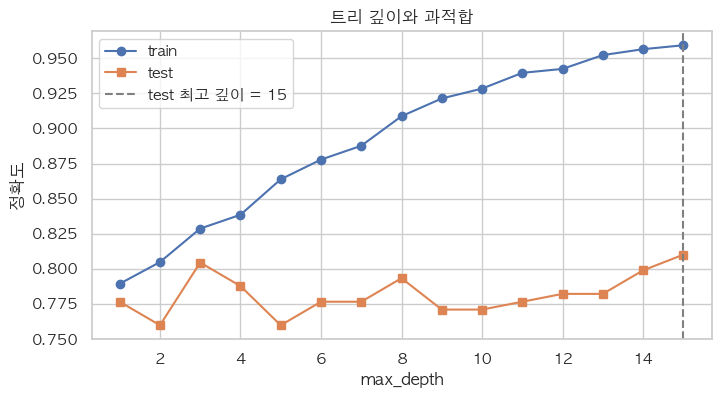

In [8]:
depths = range(1, 16)
train_acc, test_acc = [], []
for d in depths:
  m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(Xc_train, yc_train)
  train_acc.append(accuracy_score(yc_train, m.predict(Xc_train)))
  test_acc.append(accuracy_score(yc_test, m.predict(Xc_test)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depths, train_acc, "o-", label="train")
ax.plot(depths, test_acc, "s-", label="test")
best_d = depths[int(np.argmax(test_acc))]
ax.axvline(best_d, color="gray", linestyle="--", label=f"test 최고 깊이 = {best_d}")
ax.set_xlabel("max_depth")
ax.set_ylabel("정확도")
ax.set_title("트리 깊이와 과적합")
ax.legend()
plt.show()

- 깊이가 얕으면 둘 다 낮습니다 (**과소적합**).
- 깊어질수록 train 은 계속 오르지만 test 는 어느 지점 이후 **떨어지거나 제자리** 입니다 (**과적합**).
- 그래프의 두 선이 벌어지기 시작하는 근처가 적당한 깊이입니다.

> ⚠️ 여기서는 설명을 위해 test 점수로 깊이를 골랐지만, 엄밀하게는 test 를 **고르는 데 쓰면 안 됩니다.** (test 를 엿본 셈) 8회차에서 **교차검증** 으로 올바르게 고르는 법을 배웁니다.

#### 트리의 주요 하이퍼파라미터

| 파라미터 | 의미 | 과적합을 줄이려면 |
|------|------|:---:|
| `max_depth` | 최대 깊이 (질문 횟수) | 작게 |
| `min_samples_split` | 이 개수 이상이어야 더 나눔 | 크게 |
| `min_samples_leaf` | 잎에 최소 이만큼 남아야 함 | 크게 |
| `max_leaf_nodes` | 잎 개수 상한 | 작게 |
| `criterion` | 불순도 기준: `"gini"`(기본), `"entropy"` | 영향 작음 |

In [9]:
tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE)
tree.fit(Xc_train, yc_train)
eval_clf("결정트리 (depth=4)", tree)

{'모델': '결정트리 (depth=4)',
 'train 정확도': 0.8329,
 'test 정확도': 0.7765,
 'test F1': 0.6552,
 'test AUC': 0.8246}

### 1.4 트리 그림으로 해석하기

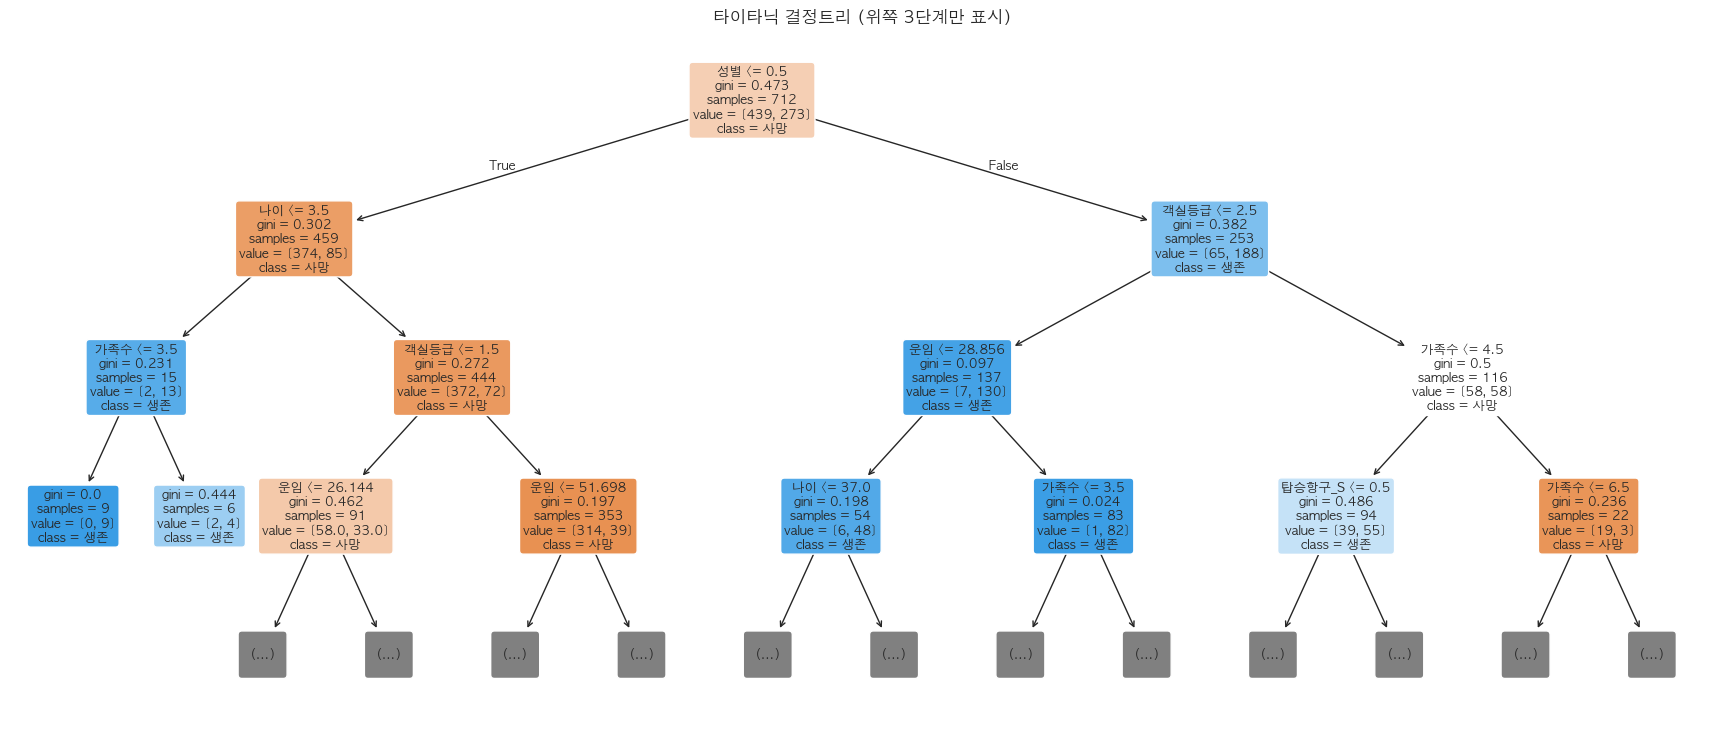

In [10]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
  tree, max_depth=3, feature_names=Xc_train.columns.tolist(), class_names=["사망", "생존"],
  filled=True, rounded=True, fontsize=9, impurity=True, proportion=False, ax=ax,
)
ax.set_title("타이타닉 결정트리 (위쪽 3단계만 표시)")
plt.show()

**노드 읽는 법** (위에서 아래로)

| 줄 | 예시 | 의미 |
|------|------|------|
| 1 | `성별 <= 0.5` | 질문. **참이면 왼쪽**, 거짓이면 오른쪽 |
| 2 | `gini = 0.47` | 이 칸의 불순도 |
| 3 | `samples = 712` | 이 칸에 도달한 승객 수 |
| 4 | `value = [439, 273]` | [사망, 생존] 인원 |
| 5 | `class = 사망` | 다수결 예측. 색이 진할수록 한쪽이 많음 |

`성별` 은 male=0, female=1 이므로 `성별 <= 0.5` 가 참(왼쪽)이면 **남성** 입니다.

In [11]:
# 텍스트로 규칙 출력: 보고서·시험 답안에 옮겨 적기 좋다
print(export_text(tree, feature_names=Xc_train.columns.tolist(), max_depth=2))

|--- 성별 <= 0.50
|   |--- 나이 <= 3.50
|   |   |--- 가족수 <= 3.50
|   |   |   |--- class: 1
|   |   |--- 가족수 >  3.50
|   |   |   |--- class: 1
|   |--- 나이 >  3.50
|   |   |--- 객실등급 <= 1.50
|   |   |   |--- truncated branch of depth 2
|   |   |--- 객실등급 >  1.50
|   |   |   |--- truncated branch of depth 2
|--- 성별 >  0.50
|   |--- 객실등급 <= 2.50
|   |   |--- 운임 <= 28.86
|   |   |   |--- truncated branch of depth 2
|   |   |--- 운임 >  28.86
|   |   |   |--- truncated branch of depth 2
|   |--- 객실등급 >  2.50
|   |   |--- 가족수 <= 4.50
|   |   |   |--- truncated branch of depth 2
|   |   |--- 가족수 >  4.50
|   |   |   |--- truncated branch of depth 2



### 1.5 변수 중요도 `feature_importances_`

각 변수가 질문으로 쓰이며 **불순도를 줄인 양의 합** 을 전체 1 로 정규화한 값입니다. 트리·랜덤포레스트·부스팅 모두 같은 속성을 가집니다.

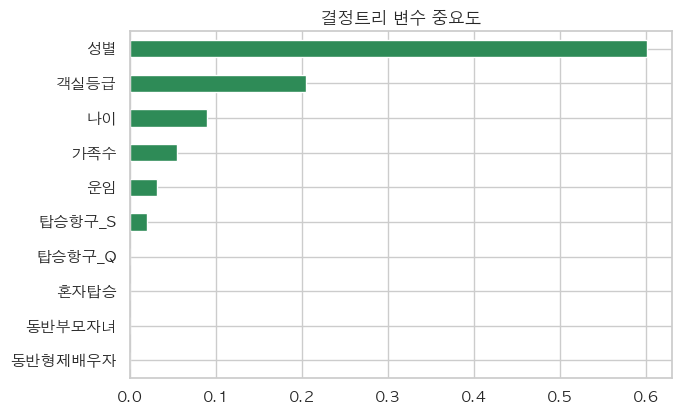

성별         0.601
객실등급       0.204
나이         0.089
가족수        0.054
운임         0.032
탑승항구_S     0.020
동반형제배우자    0.000
동반부모자녀     0.000
혼자탑승       0.000
탑승항구_Q     0.000
dtype: float64

In [12]:
def plot_importance(model, columns, title: str, top: int = 10) -> pd.Series:
  imp = pd.Series(model.feature_importances_, index=columns).sort_values(ascending=False).head(top)
  fig, ax = plt.subplots(figsize=(7, 0.35 * len(imp) + 1))
  imp.sort_values().plot(kind="barh", ax=ax, color="seagreen")
  ax.set_title(title)
  plt.show()
  return imp.round(3)


plot_importance(tree, Xc_train.columns, "결정트리 변수 중요도")

> **주의**: 중요도는 "얼마나 자주·효과적으로 질문에 쓰였나" 이지 **방향(생존에 유리/불리)** 은 알려 주지 않습니다. 방향은 트리 그림이나 3회차식 EDA 로 확인합니다. 또 서로 비슷한 변수(가족수와 동반형제배우자)가 있으면 중요도가 나뉘어 각각 낮게 나올 수 있습니다.

### 1.6 트리는 스케일링이 필요 없다

In [13]:
scaled = make_pipeline(StandardScaler(), DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE))
scaled.fit(Xc_train, yc_train)
print("스케일링 없음:", accuracy_score(yc_test, tree.predict(Xc_test)))
print("스케일링 있음:", accuracy_score(yc_test, scaled.predict(Xc_test)))
print("-> 트리는 '나이 <= 6.5' 처럼 값의 순서로만 자르므로, 단위를 바꿔도 같은 곳을 자른다")

스케일링 없음: 0.776536312849162
스케일링 있음: 0.776536312849162
-> 트리는 '나이 <= 6.5' 처럼 값의 순서로만 자르므로, 단위를 바꿔도 같은 곳을 자른다


### 1.7 회귀 트리 (캘리포니아 주택)

회귀 트리는 잎에 모인 데이터의 **평균** 을 예측값으로 냅니다. 불순도 대신 **MSE(분산)** 를 가장 많이 줄이는 질문을 고릅니다. 그래서 예측이 **계단 모양** 이 됩니다.

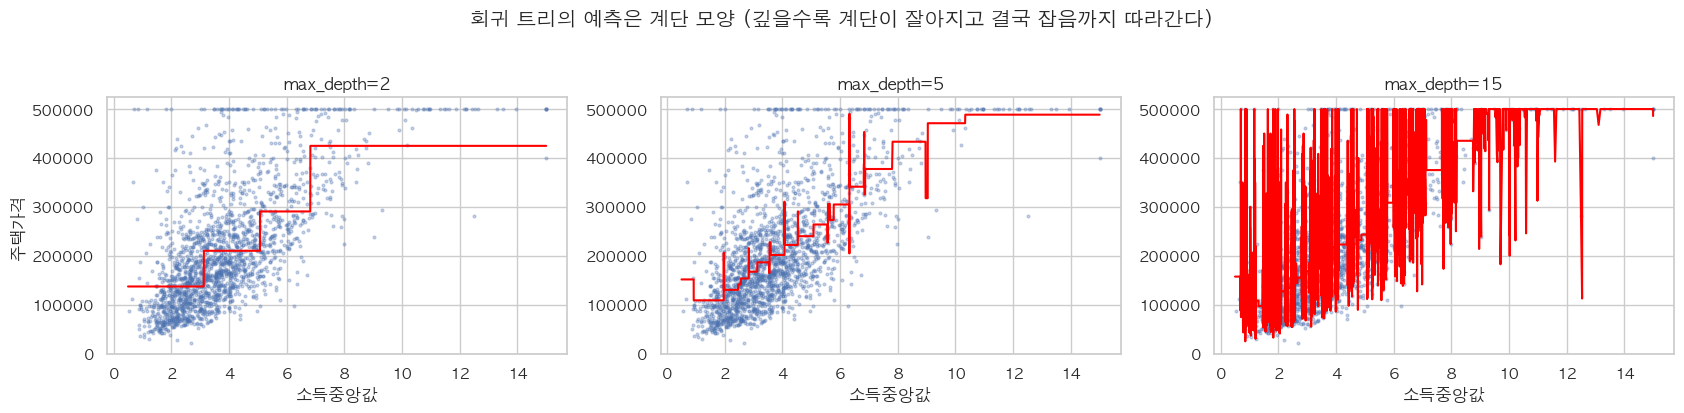

In [14]:
from sklearn.tree import DecisionTreeRegressor

x_one = Xr_train[["소득중앙값"]]
order = np.argsort(x_one["소득중앙값"].values)
sample = Xr_train.sample(2000, random_state=0).index

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, d in zip(axes, [2, 5, 15]):
  m = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE).fit(x_one, yr_train)
  ax.scatter(Xr_train.loc[sample, "소득중앙값"], yr_train[sample], s=4, alpha=0.3)
  ax.plot(x_one.values[order], m.predict(x_one)[order], color="red", linewidth=1.5)
  ax.set_title(f"max_depth={d}")
  ax.set_xlabel("소득중앙값")
axes[0].set_ylabel("주택가격")
plt.suptitle("회귀 트리의 예측은 계단 모양 (깊을수록 계단이 잘아지고 결국 잡음까지 따라간다)", y=1.03)
plt.tight_layout()
plt.show()

In [15]:
for d in [None, 10, 8]:
  m = DecisionTreeRegressor(max_depth=d, min_samples_leaf=10 if d else 1, random_state=RANDOM_STATE).fit(Xr_train, yr_train)
  print(eval_reg(f"회귀트리 (depth={d})", m))

{'모델': '회귀트리 (depth=None)', 'train R2': 1.0, 'test R2': 0.6427, 'test RMSE': 70167}
{'모델': '회귀트리 (depth=10)', 'train R2': 0.8229, 'test R2': 0.7428, 'test RMSE': 59527}


{'모델': '회귀트리 (depth=8)', 'train R2': 0.7748, 'test R2': 0.7163, 'test RMSE': 62518}


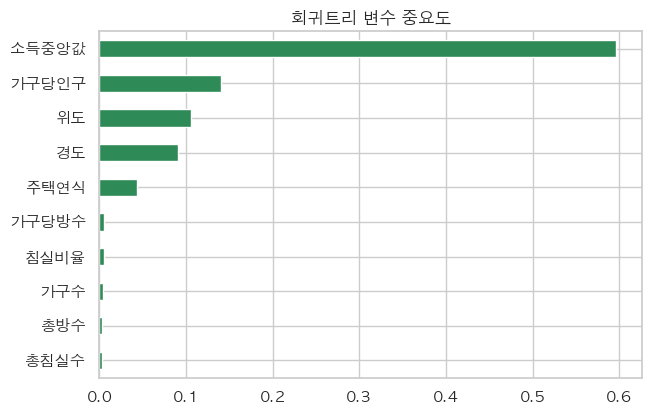

소득중앙값    0.596
가구당인구    0.141
위도       0.106
경도       0.091
주택연식     0.044
가구당방수    0.006
침실비율     0.006
가구수      0.004
총방수      0.003
총침실수     0.002
dtype: float64

In [16]:
reg_tree = DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, random_state=RANDOM_STATE).fit(Xr_train, yr_train)
plot_importance(reg_tree, Xr_train.columns, "회귀트리 변수 중요도")

소득중앙값이 압도적이고, 그다음으로 가구당인구·위도·경도가 이어집니다. 위도·경도가 상위권에 들어온 점이 선형회귀와 다릅니다. 선형회귀는 "위도가 1 커지면 가격이 w 만큼" 이라는 **직선** 밖에 못 그리지만, 트리는 "위도 34~35 이면서 경도 -118.5 근처(로스앤젤레스)" 같은 **구역** 을 질문으로 잘라낼 수 있기 때문입니다.

### 📝 시험 출제 포인트 (1장)

- "`max_depth=5`, `random_state=42` 인 결정트리로 학습" → `DecisionTreeClassifier(max_depth=5, random_state=42)`
- "변수 중요도를 내림차순 출력" → `pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)`
- "train/test 정확도를 비교하여 과적합 여부 판단" → 둘 다 출력
- 회귀는 `DecisionTreeRegressor`

### ⚠️ 자주 하는 실수 (1장)

- **`random_state` 생략**: 같은 불순도의 질문이 여럿이면 무작위로 골라 실행마다 결과가 달라집니다. 시험은 지정값을 반드시 넣습니다.
- **제한 없는 트리를 그대로 사용**: train 1.0 은 자랑이 아니라 과적합 신호입니다.
- **중요도를 방향으로 해석**: "성별 중요도가 높다 = 여성이 유리하다" 는 중요도만으로는 알 수 없습니다.
- **`plot_tree` 를 깊은 트리에 그대로**: 글씨가 안 보입니다. `max_depth=3` 옵션으로 위쪽만 그립니다.

---
## 2. 앙상블 (Ensemble)

### 한 줄 정의
**여러 모델의 예측을 합쳐서** 하나보다 나은 예측을 만드는 방법.

### 직관적 설명
퀴즈 프로그램의 "청중 찬스" 입니다. 한 사람은 틀릴 수 있어도, 서로 **다르게 틀리는** 여러 사람의 답을 모으면 정답률이 올라갑니다. 핵심은 **모델들이 서로 달라야(다양성)** 한다는 것입니다. 똑같은 모델 100개는 1개와 같습니다.

| 방식 | 다양성을 만드는 방법 | 합치는 방법 | 대표 모델 | 주로 줄이는 것 |
|------|------|------|------|------|
| **보팅** (Voting) | **서로 다른 알고리즘** | 다수결(hard) / 확률 평균(soft) | `VotingClassifier` | — |
| **배깅** (Bagging) | 같은 알고리즘, **데이터를 다르게 뽑아서** (복원 추출) | 평균 / 다수결 | **랜덤포레스트** | 분산 (과적합) |
| **부스팅** (Boosting) | 같은 알고리즘, **앞 모델이 틀린 것을 다음 모델이 집중** 학습 | 가중 합 | **그라디언트부스팅**, XGBoost, LightGBM | 편향 (과소적합) |

```
배깅:   데이터 ─┬─ 표본1 → 트리1 ─┐
               ├─ 표본2 → 트리2 ─┼─ 평균/투표 → 예측      (동시에, 독립적으로)
               └─ 표본3 → 트리3 ─┘

부스팅: 데이터 → 트리1 → (틀린 부분) → 트리2 → (남은 오차) → 트리3 → ... → 합   (순서대로, 이어서)
```

### 2.1 보팅: 서로 다른 모델의 투표

In [17]:
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier

voters = [
  ("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
  ("tree", DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE)),
  ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7))),   # 가까운 7명의 다수결 (참고용)
]
for name, m in voters:
  m.fit(Xc_train, yc_train)
  print(f"{name:<5} 단독 test 정확도: {accuracy_score(yc_test, m.predict(Xc_test)):.4f}")

for voting in ["hard", "soft"]:
  vote = VotingClassifier(estimators=voters, voting=voting).fit(Xc_train, yc_train)
  print(f"보팅({voting}) test 정확도: {accuracy_score(yc_test, vote.predict(Xc_test)):.4f}")

lr    단독 test 정확도: 0.8045
tree  단독 test 정확도: 0.7765
knn   단독 test 정확도: 0.8045
보팅(hard) test 정확도: 0.7877
보팅(soft) test 정확도: 0.8045


- `hard`: 각 모델의 **예측 클래스** 로 다수결
- `soft`: 각 모델의 **확률을 평균** 낸 뒤 0.5 기준. 자신 있는 모델의 목소리가 커서 보통 hard 보다 낫습니다.

보팅이 항상 최고 단독 모델을 이기지는 않습니다. 이 데이터처럼 test 가 179명뿐이면 한두 명 차이로 순위가 바뀌므로, 평균적으로 **안정적** 이라는 점에 의미를 둡니다.

### 2.2 배깅: 같은 트리, 다른 데이터

In [18]:
from sklearn.ensemble import BaggingClassifier

# 부트스트랩: 712명 중 712명을 '복원 추출' -> 어떤 승객은 여러 번, 약 37% 는 한 번도 안 뽑힌다
rng = np.random.default_rng(0)
boot = rng.choice(len(Xc_train), size=len(Xc_train), replace=True)
print(f"부트스트랩 표본의 고유 승객 비율: {len(np.unique(boot)) / len(Xc_train):.3f}  (이론값 1 - 1/e = 0.632)")

bag = BaggingClassifier(
  estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),   # 제한 없는(과적합된) 트리 100개
  n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1,
).fit(Xc_train, yc_train)
print(eval_clf("배깅 (트리 100개)", bag))

부트스트랩 표본의 고유 승객 비율: 0.646  (이론값 1 - 1/e = 0.632)


{'모델': '배깅 (트리 100개)', 'train 정확도': 0.9817, 'test 정확도': 0.8101, 'test F1': 0.7424, 'test AUC': 0.8243}


1.2 의 **제한 없는 트리 1개** 와 비교해 보세요. 똑같이 과적합된 트리라도 **서로 다른 표본으로 100개를 만들어 투표** 하면 test 점수가 올라갑니다. 각 트리의 "외운 잡음" 이 서로 달라서 평균을 내면 상쇄되기 때문입니다 (**분산 감소**).

---
## 3. 랜덤포레스트 (Random Forest)

### 한 줄 정의
**배깅 + 변수 무작위 선택**. 트리마다 다른 표본을 쓰고, 노드를 나눌 때마다 **일부 변수만 후보로** 써서 트리들을 더 다르게 만든 모델.

### 직관적 설명
배깅만 하면 모든 트리가 첫 질문으로 "성별" 을 고릅니다. 가장 강한 변수가 늘 이기니까요. 그러면 트리들이 서로 닮아 앙상블 효과가 줄어듭니다. 랜덤포레스트는 각 질문마다 **변수 몇 개를 제비뽑기** 해서 그중에서만 고르게 합니다. 어떤 트리는 성별 없이 객실등급·나이로 판단하는 법을 배우게 되어 **숲 전체가 다양** 해집니다.

| 파라미터 | 의미 | 기본값 | 조정 방향 |
|------|------|------|------|
| `n_estimators` | 트리 개수 | 100 | 많을수록 안정 (어느 수준 이후 효과 정체, 시간만 증가) |
| `max_features` | 노드마다 후보 변수 수 | 분류 `"sqrt"`, 회귀 `1.0` | 작을수록 다양성↑ |
| `max_depth` | 트리 최대 깊이 | None (끝까지) | 과적합이면 제한 |
| `min_samples_leaf` | 잎 최소 샘플 | 1 | 과적합이면 크게 |
| `n_jobs` | 사용할 CPU 코어 | None | `-1` = 전부 (빠름) |
| `oob_score` | 안 뽑힌 37% 로 자체 검증 | False | True 면 `oob_score_` 확인 |

### 3.1 분류: 타이타닉

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, oob_score=True)
rf.fit(Xc_train, yc_train)
print("OOB 정확도 (train 안에서 자체 검증):", round(rf.oob_score_, 4))
print(eval_clf("랜덤포레스트 (기본)", rf))

OOB 정확도 (train 안에서 자체 검증): 0.809
{'모델': '랜덤포레스트 (기본)', 'train 정확도': 0.9817, 'test 정확도': 0.8156, 'test F1': 0.7519, 'test AUC': 0.8413}


기본 설정은 트리를 끝까지 키우므로 train 정확도가 매우 높습니다. 과적합 기미가 보이면 **트리를 조금 제한** 합니다.

In [20]:
rows = []
for leaf in [1, 3, 5, 10]:
  for depth in [None, 6, 8]:
    m = RandomForestClassifier(n_estimators=200, max_depth=depth, min_samples_leaf=leaf,
                               random_state=RANDOM_STATE, n_jobs=-1, oob_score=True).fit(Xc_train, yc_train)
    rows.append({"max_depth": str(depth), "min_samples_leaf": leaf,
                 "train": round(m.score(Xc_train, yc_train), 3), "OOB": round(m.oob_score_, 3)})
grid = pd.DataFrame(rows)
grid.pivot(index="min_samples_leaf", columns="max_depth", values="OOB")

max_depth,6,8,None
min_samples_leaf,,,
1,0.819,0.829,0.809
3,0.820,0.824,0.826
5,0.809,0.813,0.817
10,0.817,0.820,0.813


위 표는 **OOB 점수** (각 트리가 학습에 쓰지 않은 승객으로 매긴 점수) 입니다. test 를 건드리지 않고 하이퍼파라미터를 고를 수 있어서 랜덤포레스트의 편리한 기능입니다.

In [21]:
best = grid.sort_values("OOB", ascending=False).iloc[0]
print("OOB 최고 조합:", best.to_dict())

rf_tuned = RandomForestClassifier(
  n_estimators=200,
  max_depth=None if best["max_depth"] == "None" else int(best["max_depth"]),
  min_samples_leaf=int(best["min_samples_leaf"]),
  random_state=RANDOM_STATE, n_jobs=-1,
).fit(Xc_train, yc_train)
eval_clf("랜덤포레스트 (OOB 로 조정)", rf_tuned)

OOB 최고 조합: {'max_depth': '8', 'min_samples_leaf': 1, 'train': 0.934, 'OOB': 0.829}


{'모델': '랜덤포레스트 (OOB 로 조정)',
 'train 정확도': 0.934,
 'test 정확도': 0.8101,
 'test F1': 0.7302,
 'test AUC': 0.8414}

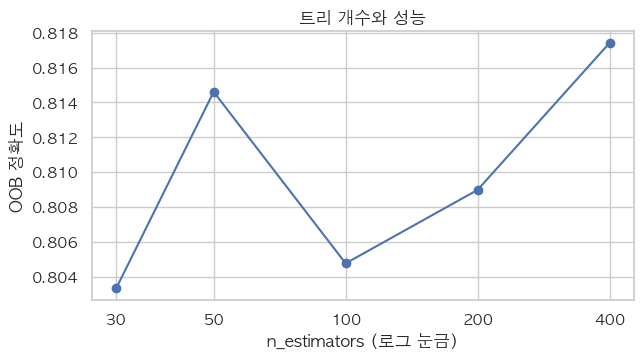

In [22]:
# 트리 개수에 따른 OOB 점수: 어느 수준을 넘으면 거의 변하지 않는다
ns = [30, 50, 100, 200, 400]     # 트리가 너무 적으면(10개 등) OOB 점수를 못 받는 승객이 생겨 경고가 난다
oob = [RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1, oob_score=True)
       .fit(Xc_train, yc_train).oob_score_ for n in ns]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ns, oob, "o-")
ax.set_xscale("log")
ax.set_xticks(ns, labels=[str(n) for n in ns])
ax.set_xlabel("n_estimators (로그 눈금)")
ax.set_ylabel("OOB 정확도")
ax.set_title("트리 개수와 성능")
plt.show()

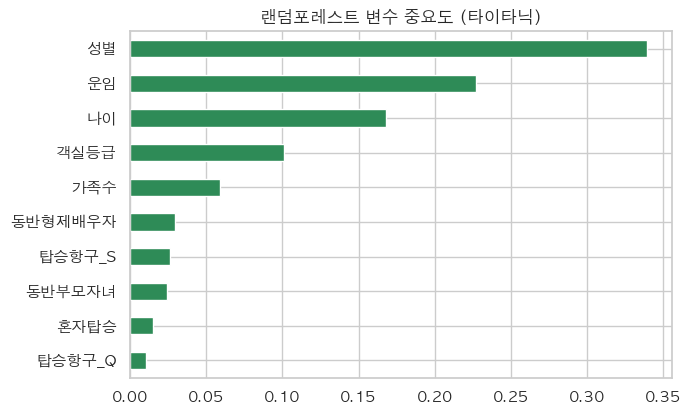

성별         0.339
운임         0.227
나이         0.168
객실등급       0.101
가족수        0.059
동반형제배우자    0.030
탑승항구_S     0.026
동반부모자녀     0.024
혼자탑승       0.015
탑승항구_Q     0.010
dtype: float64

In [23]:
plot_importance(rf_tuned, Xc_train.columns, "랜덤포레스트 변수 중요도 (타이타닉)")

결정트리 1개와 비교하면 중요도가 **여러 변수에 고르게 퍼져** 있습니다. 변수 무작위 선택 덕분에 성별 외의 변수들도 질문으로 쓰일 기회를 얻었기 때문입니다.

### 3.2 회귀: 캘리포니아 주택

In [24]:
from sklearn.ensemble import RandomForestRegressor

start = time.time()
rf_reg = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, max_features=0.5,
                               random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(Xr_train, yr_train)
print(f"학습 시간: {time.time() - start:.1f}초 (17,000행 x 트리 200개)")
eval_reg("랜덤포레스트 회귀", rf_reg)

학습 시간: 1.7초 (17,000행 x 트리 200개)


{'모델': '랜덤포레스트 회귀', 'train R2': 0.9555, 'test R2': 0.8161, 'test RMSE': 50342}

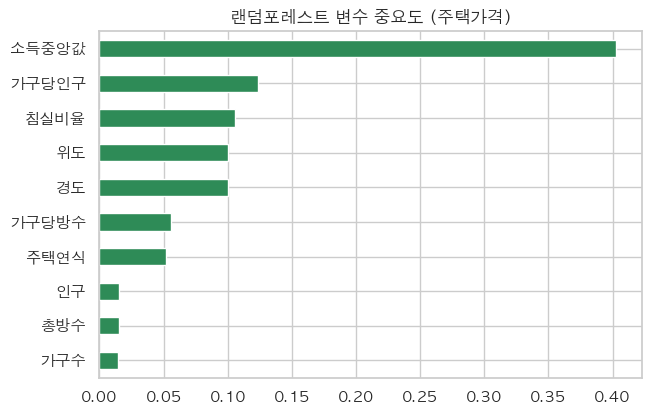

소득중앙값    0.403
가구당인구    0.124
침실비율     0.105
위도       0.100
경도       0.100
가구당방수    0.056
주택연식     0.052
인구       0.015
총방수      0.015
가구수      0.015
dtype: float64

In [25]:
plot_importance(rf_reg, Xr_train.columns, "랜덤포레스트 변수 중요도 (주택가격)")

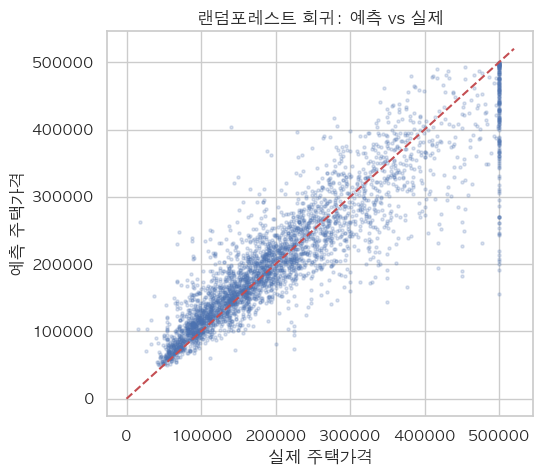

In [26]:
pred = rf_reg.predict(Xr_test)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(yr_test, pred, s=5, alpha=0.2)
ax.plot([0, 520000], [0, 520000], "r--")
ax.set_xlabel("실제 주택가격")
ax.set_ylabel("예측 주택가격")
ax.set_title("랜덤포레스트 회귀: 예측 vs 실제")
plt.show()

5회차 선형회귀의 같은 그림과 비교하면 점들이 대각선에 훨씬 가깝게 모입니다. 단, 트리 계열은 **학습 데이터의 최댓값을 넘는 값을 예측하지 못합니다.** 잎의 평균을 내기 때문입니다 (그래서 500,001 상한 근처에서 예측이 눌립니다).

### 📝 시험 출제 포인트 (2·3장)

- "랜덤포레스트로 학습, `n_estimators=100`, `random_state=42`" → `RandomForestClassifier(n_estimators=100, random_state=42)`
- 회귀는 `RandomForestRegressor`
- "변수 중요도 상위 5개" → `feature_importances_` 정렬 후 `head(5)`
- 배깅 vs 부스팅 차이: **배깅은 병렬·독립(분산↓), 부스팅은 순차·오차 보정(편향↓)**

### ⚠️ 자주 하는 실수 (2·3장)

- **`n_estimators` 를 무작정 크게**: 성능은 어느 수준에서 멈추고 시간만 늘어납니다.
- **`n_jobs=-1` 미사용**: 큰 데이터에서 학습이 느립니다. 시험 시간 절약용으로 습관화.
- **랜덤포레스트에 스케일링 필수라고 생각**: 필요 없습니다. 해도 결과는 같습니다.
- **`oob_score_` 를 `oob_score=True` 없이 호출**: `AttributeError`.

---
## 4. 그라디언트부스팅 (Gradient Boosting)

### 한 줄 정의
**얕은 트리를 순서대로 쌓으면서, 각 트리가 앞까지의 예측이 남긴 오차(잔차)를 맞히도록** 학습하는 모델.

### 직관적 설명
골프입니다. 첫 샷(트리1)으로 대충 홀 근처로 보내고, 두 번째 샷(트리2)은 **남은 거리** 만큼만 칩니다. 세 번째는 또 남은 거리를... 샷 하나하나는 약하지만(얕은 트리) 이어 치면 홀에 가까워집니다.

```
예측 = 평균 + η × 트리1(오차) + η × 트리2(남은 오차) + η × 트리3(...) + ...
                ↑ learning_rate (보폭): 한 번에 얼마나 고칠지
```

| 파라미터 | 의미 | 기본값 | 관계 |
|------|------|------|------|
| `n_estimators` | 트리 개수 (샷 횟수) | 100 | 많을수록 train 에 더 맞춤 → 과적합 위험 |
| `learning_rate` | 보폭 η | 0.1 | **작게 하면 트리를 더 많이** 써야 함. 작은 보폭 + 많은 트리가 보통 더 좋음 |
| `max_depth` | 각 트리 깊이 | 3 | 부스팅은 **얕은 트리(2~5)** 가 원칙 |
| `subsample` | 트리마다 쓸 데이터 비율 | 1.0 | 0.8 정도로 낮추면 과적합 감소 |

### 4.1 잔차를 이어서 맞힌다는 것: 그림으로 보기

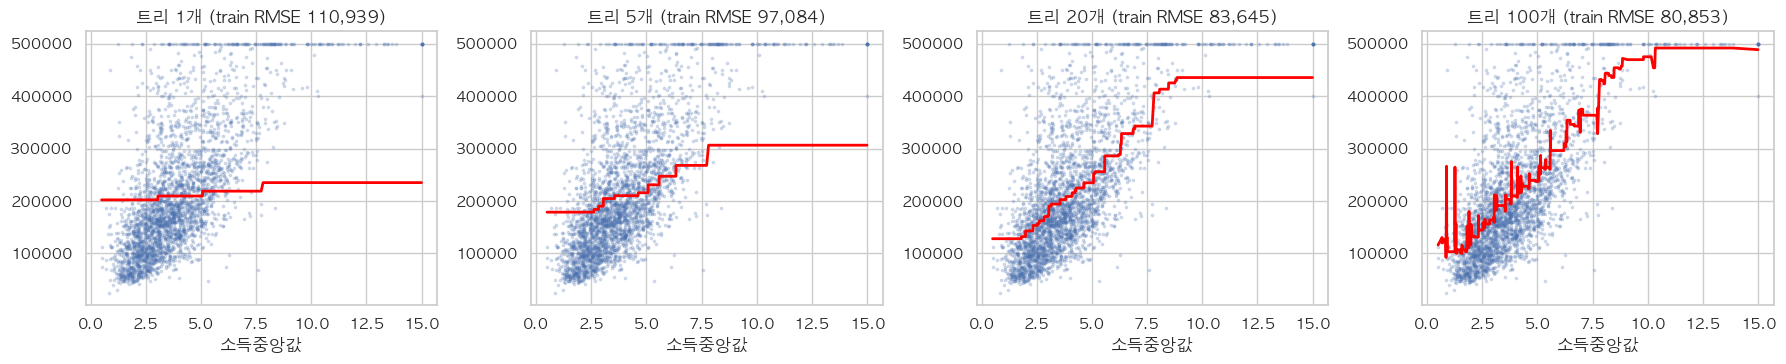

In [27]:
from sklearn.ensemble import GradientBoostingRegressor

x1 = Xr_train[["소득중앙값"]].iloc[:3000]
y1 = yr_train.iloc[:3000]
order1 = np.argsort(x1["소득중앙값"].values)

gb_demo = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=RANDOM_STATE).fit(x1, y1)
stages = list(gb_demo.staged_predict(x1))       # 트리를 1개, 2개, ... 쌓았을 때의 예측

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, k in zip(axes, [1, 5, 20, 100]):
  ax.scatter(x1["소득중앙값"], y1, s=3, alpha=0.2)
  ax.plot(x1.values[order1], stages[k - 1][order1], color="red", linewidth=2)
  rmse = np.sqrt(mean_squared_error(y1, stages[k - 1]))
  ax.set_title(f"트리 {k}개 (train RMSE {rmse:,.0f})")
  ax.set_xlabel("소득중앙값")
plt.tight_layout()
plt.show()

트리 1개일 때는 평균 근처에서 거의 움직이지 않다가, 트리를 쌓을수록 예측선이 데이터 모양을 따라갑니다. 각 트리는 깊이 2짜리 **아주 약한 모델** 인데도 이어 붙이면 강해집니다.

### 4.2 분류: 타이타닉

In [28]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=RANDOM_STATE)        # 기본: 100개, 0.1, 깊이 3
gb.fit(Xc_train, yc_train)
eval_clf("그라디언트부스팅 (기본)", gb)

{'모델': '그라디언트부스팅 (기본)',
 'train 정확도': 0.9045,
 'test 정확도': 0.8045,
 'test F1': 0.72,
 'test AUC': 0.8206}

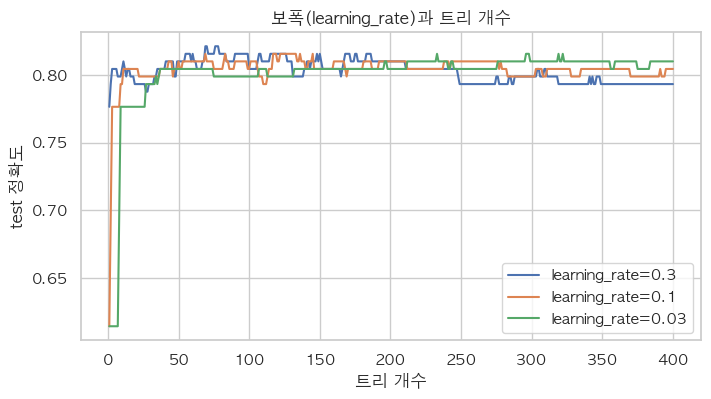

In [29]:
# learning_rate 와 n_estimators 의 관계: 보폭이 작으면 더 많은 트리가 필요하다
fig, ax = plt.subplots(figsize=(8, 4))
for lr in [0.3, 0.1, 0.03]:
  m = GradientBoostingClassifier(n_estimators=400, learning_rate=lr, max_depth=3, random_state=RANDOM_STATE).fit(Xc_train, yc_train)
  test_curve = [accuracy_score(yc_test, p) for p in m.staged_predict(Xc_test)]
  ax.plot(range(1, 401), test_curve, label=f"learning_rate={lr}")
ax.set_xlabel("트리 개수")
ax.set_ylabel("test 정확도")
ax.set_title("보폭(learning_rate)과 트리 개수")
ax.legend()
plt.show()

- 보폭이 크면(0.3) 빨리 오르지만 곧 **과적합** 으로 흔들리거나 떨어집니다.
- 보폭이 작으면(0.03) 천천히 오르고, 더 많은 트리가 필요합니다.
- 실무 기본 전략: **learning_rate 를 0.05~0.1 로 두고 n_estimators 를 조정** 합니다.

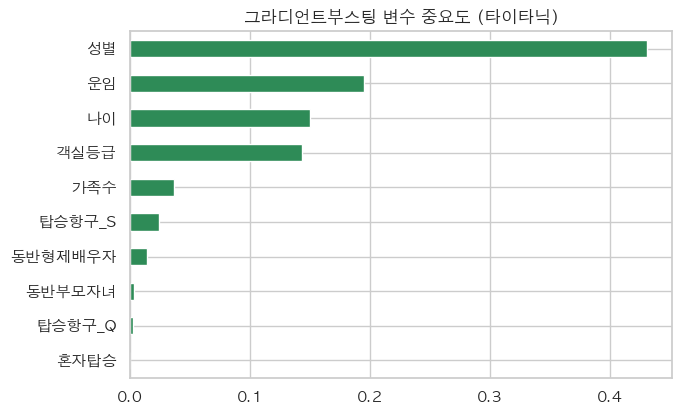

성별         0.430
운임         0.195
나이         0.150
객실등급       0.143
가족수        0.037
탑승항구_S     0.024
동반형제배우자    0.014
동반부모자녀     0.003
탑승항구_Q     0.003
혼자탑승       0.000
dtype: float64

In [30]:
gb_tuned = GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=3, subsample=0.8,
                                      random_state=RANDOM_STATE).fit(Xc_train, yc_train)
eval_clf("그라디언트부스팅 (lr=0.05, subsample=0.8)", gb_tuned)
plot_importance(gb_tuned, Xc_train.columns, "그라디언트부스팅 변수 중요도 (타이타닉)")

### 4.3 회귀: 캘리포니아 주택

In [31]:
start = time.time()
gb_reg = GradientBoostingRegressor(n_estimators=400, learning_rate=0.1, max_depth=5, subsample=0.8,
                                   random_state=RANDOM_STATE).fit(Xr_train, yr_train)
print(f"학습 시간: {time.time() - start:.1f}초")
eval_reg("그라디언트부스팅 회귀", gb_reg)

학습 시간: 21.3초


{'모델': '그라디언트부스팅 회귀',
 'train R2': 0.9463,
 'test R2': 0.8453,
 'test RMSE': 46168}

### 4.4 XGBoost 와 LightGBM

그라디언트부스팅을 **더 빠르고 강하게** 구현한 외부 라이브러리입니다. 사용법은 scikit-learn 과 똑같이 `fit` / `predict` 입니다. Colab 에는 둘 다 설치되어 있고, 로컬에서는 `pip install xgboost lightgbm` 이 필요합니다.

| 라이브러리 | 특징 | 분류 / 회귀 클래스 |
|------|------|------|
| scikit-learn `GradientBoosting*` | 기본 제공, 느린 편 | `GradientBoostingClassifier` / `Regressor` |
| **XGBoost** | 규제 내장, 결측 자동 처리, 대회 단골 | `XGBClassifier` / `XGBRegressor` |
| **LightGBM** | 매우 빠름, 대용량에 강함 | `LGBMClassifier` / `LGBMRegressor` |
| scikit-learn `HistGradientBoosting*` | LightGBM 방식을 sklearn 에 내장, 결측 자동 처리 | `HistGradientBoostingClassifier` / `Regressor` |

In [32]:
try:
  from xgboost import XGBClassifier, XGBRegressor

  xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8,
                      colsample_bytree=0.8, random_state=RANDOM_STATE, eval_metric="logloss")
  xgb.fit(Xc_train, yc_train)
  print(eval_clf("XGBoost", xgb))

  xgb_reg = XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.8,
                         colsample_bytree=0.8, random_state=RANDOM_STATE)
  xgb_reg.fit(Xr_train, yr_train)
  print(eval_reg("XGBoost 회귀", xgb_reg))
except ImportError:
  print("xgboost 가 설치되어 있지 않습니다: pip install xgboost")

{'모델': 'XGBoost', 'train 정확도': 0.9242, 'test 정확도': 0.8045, 'test F1': 0.7287, 'test AUC': 0.8152}


{'모델': 'XGBoost 회귀', 'train R2': 0.9574, 'test R2': 0.8548, 'test RMSE': 44721}


In [33]:
try:
  from lightgbm import LGBMClassifier

  lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, random_state=RANDOM_STATE, verbose=-1)
  lgbm.fit(Xc_train, yc_train)
  print(eval_clf("LightGBM", lgbm))
except ImportError:
  print("lightgbm 이 설치되어 있지 않습니다: pip install lightgbm  (Colab 에는 기본 설치)")

lightgbm 이 설치되어 있지 않습니다: pip install lightgbm  (Colab 에는 기본 설치)


In [34]:
# HistGradientBoosting: 추가 설치 없이 쓸 수 있는 빠른 부스팅. 결측(NaN)을 그대로 넣어도 학습된다
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.1, random_state=RANDOM_STATE).fit(Xr_train, yr_train)
eval_reg("HistGradientBoosting 회귀", hgb)

{'모델': 'HistGradientBoosting 회귀',
 'train R2': 0.9178,
 'test R2': 0.8482,
 'test RMSE': 45736}

### 📝 시험 출제 포인트 (4장)

- "`GradientBoostingClassifier` 로 학습, `n_estimators=200`, `learning_rate=0.05`" → 그대로 파라미터 지정
- 회귀는 `GradientBoostingRegressor`
- XGBoost 가 허용되는 환경이면 `XGBClassifier` 도 동일한 `fit`/`predict`
- `learning_rate` 를 줄이면 `n_estimators` 를 늘려야 한다는 관계

### ⚠️ 자주 하는 실수 (4장)

- **부스팅에 깊은 트리**: 랜덤포레스트처럼 깊게 키우면 몇 개만으로 train 을 외워 과적합됩니다. `max_depth` 3~6.
- **`learning_rate` 만 낮추고 트리 수는 그대로**: 학습이 덜 되어 오히려 점수가 떨어집니다.
- **XGBoost 에 문자열 컬럼**: 인코딩은 여전히 필요합니다 (결측은 자동 처리해도 문자열은 못 받음).
- **랜덤포레스트와 혼동**: 부스팅은 순차 학습이라 `n_jobs` 로 트리를 병렬화하지 못합니다 (sklearn 기준). 대신 XGBoost·LightGBM 은 내부 병렬화가 됩니다.

---
## 5. 모델 비교: 같은 데이터, 같은 지표

지금까지 `eval_clf`, `eval_reg` 로 쌓아 온 결과를 한 표로 봅니다.

### 5.1 분류 (타이타닉, test 179명)

In [35]:
clf_table = pd.DataFrame(clf_results).drop_duplicates("모델", keep="last").set_index("모델")
clf_table["과적합 정도(train-test)"] = (clf_table["train 정확도"] - clf_table["test 정확도"]).round(3)
clf_table.sort_values("test AUC", ascending=False)

,train 정확도,test 정확도,test F1,test AUC,과적합 정도(train-test)
모델,,,,,
로지스틱 회귀 (5회차),0.8006,0.8045,0.7287,0.8502,-0.004
랜덤포레스트 (OOB 로 조정),0.9340,0.8101,0.7302,0.8414,0.124
랜덤포레스트 (기본),0.9817,0.8156,0.7519,0.8413,0.166
"그라디언트부스팅 (lr=0.05, subsample=0.8)",0.9087,0.8101,0.7302,0.8294,0.099
결정트리 (depth=4),0.8329,0.7765,0.6552,0.8246,0.056
배깅 (트리 100개),0.9817,0.8101,0.7424,0.8243,0.172
그라디언트부스팅 (기본),0.9045,0.8045,0.7200,0.8206,0.100
XGBoost,0.9242,0.8045,0.7287,0.8152,0.120
결정트리 (제한 없음),0.9817,0.8045,0.7407,0.7807,0.177


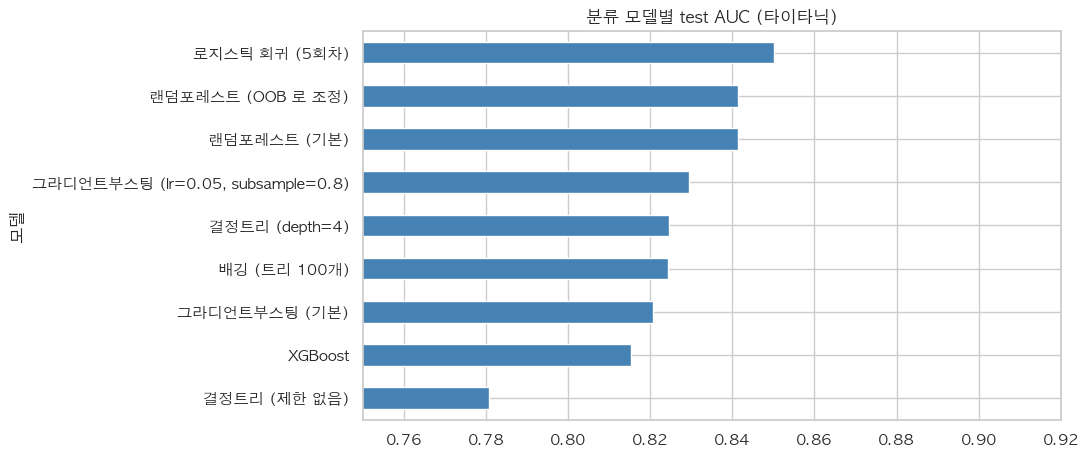

In [36]:
fig, ax = plt.subplots(figsize=(9, 0.45 * len(clf_table) + 1))
clf_table["test AUC"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlim(0.75, 0.92)
ax.set_title("분류 모델별 test AUC (타이타닉)")
plt.show()

**읽는 법**

- test 가 179명이라 **정확도 0.01 = 약 2명** 차이입니다. 작은 차이로 순위를 단정하지 마세요. 확률 기반이라 덜 흔들리는 **AUC** 와 **과적합 정도** 를 함께 봅니다.
- 제한 없는 결정트리는 과적합 정도가 가장 크고 AUC 도 가장 낮습니다. 같은 트리를 배깅으로 100개 묶으면 과적합 정도는 비슷해도 **test AUC 가 뚜렷이 오릅니다.** 트리를 제한한 랜덤포레스트·부스팅은 과적합 정도 자체도 줄어듭니다.
- 891명짜리 작은 표 데이터에서는 잘 만든 로지스틱 회귀도 앙상블과 비슷하게 경쟁합니다. **데이터가 작고 관계가 단순하면 단순한 모델이 충분** 할 수 있습니다.

### 5.2 회귀 (캘리포니아 주택, test 3,400구역)

In [37]:
reg_table = pd.DataFrame(reg_results).drop_duplicates("모델", keep="last").set_index("모델")
reg_table["과적합 정도(train-test)"] = (reg_table["train R2"] - reg_table["test R2"]).round(3)
reg_table.sort_values("test R2", ascending=False)

,train R2,test R2,test RMSE,과적합 정도(train-test)
모델,,,,
XGBoost 회귀,0.9574,0.8548,44721,0.103
HistGradientBoosting 회귀,0.9178,0.8482,45736,0.070
그라디언트부스팅 회귀,0.9463,0.8453,46168,0.101
랜덤포레스트 회귀,0.9555,0.8161,50342,0.139
회귀트리 (depth=10),0.8229,0.7428,59527,0.080
회귀트리 (depth=8),0.7748,0.7163,62518,0.058
선형회귀 (5회차),0.6463,0.6696,67471,-0.023
회귀트리 (depth=None),1.0000,0.6427,70167,0.357


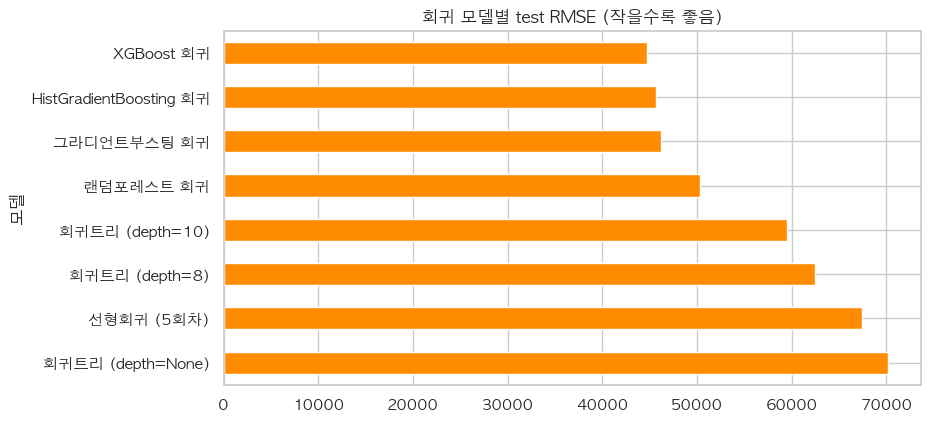

In [38]:
fig, ax = plt.subplots(figsize=(9, 0.45 * len(reg_table) + 1))
reg_table["test RMSE"].sort_values(ascending=False).plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("회귀 모델별 test RMSE (작을수록 좋음)")
plt.show()

**읽는 법**

- 회귀에서는 차이가 뚜렷합니다. 선형회귀 대비 랜덤포레스트·부스팅의 RMSE 가 크게 줄었습니다. 위치(위도·경도)처럼 **직선으로 표현할 수 없는 관계** 가 많은 데이터일수록 트리 앙상블이 유리합니다.
- 랜덤포레스트는 train R² 가 매우 높아 과적합 정도가 커 보이지만, test 점수도 높습니다. 배깅은 **train 을 외워도 평균이 잡음을 지워 test 가 좋게 나오는** 특이한 모델입니다. 판단은 항상 test 점수로 합니다.

### 5.3 별도 테스트 파일로 최종 확인 (회귀)

In [39]:
X_final = add_features(housing_test).drop(columns=["주택가격"])
y_final = housing_test["주택가격"]
final = []
for name, m in [("선형회귀 (5회차)", base_reg), ("랜덤포레스트 회귀", rf_reg), ("그라디언트부스팅 회귀", gb_reg)]:
  p = m.predict(X_final)
  final.append({"모델": name, "R2": round(r2_score(y_final, p), 4), "RMSE": int(np.sqrt(mean_squared_error(y_final, p)))})
pd.DataFrame(final).set_index("모델")

,R2,RMSE
모델,,
선형회귀 (5회차),0.6290,68893
랜덤포레스트 회귀,0.7957,51126
그라디언트부스팅 회귀,0.8266,47099


### 5.4 어떤 모델을 고를까

| 상황 | 추천 | 이유 |
|------|------|------|
| 설명이 가장 중요 (규칙을 보여 줘야 함) | 결정트리 (얕게), 로지스틱/선형 회귀 | 사람이 읽을 수 있음 |
| 일단 좋은 성능을 빠르게 | **랜덤포레스트** | 튜닝을 덜 해도 안정적, 과적합에 강함 |
| 최고 성능을 노림 | **그라디언트부스팅 계열** (XGBoost, LightGBM) | 튜닝하면 대개 최고 |
| 데이터가 작고 관계가 단순 | 로지스틱/선형 회귀 | 앙상블 이득이 작음 |
| 스케일링·이상치 처리할 시간이 없음 | 트리 계열 | 둘 다 거의 영향 없음 |

> **AICE 시험 팁**: 문제가 모델을 지정하지 않고 "성능이 좋은 모델" 을 요구하면, **랜덤포레스트를 먼저** 학습시켜 기준을 잡은 뒤 시간이 남으면 부스팅을 시도하는 순서가 안전합니다.

---
## 6. 종합 실습

0장에서 만든 `Xc_train, Xc_test, yc_train, yc_test` (타이타닉), `Xr_train, Xr_test, yr_train, yr_test` (주택) 를 그대로 사용합니다.

### 문제 1. 결정트리와 과적합

`max_depth` 를 3, 5, 7, 9 로 바꿔 가며 `DecisionTreeClassifier(random_state=0)` 를 학습시키고, 깊이별 train·test 정확도를 DataFrame 으로 출력하시오. 과적합이 시작되는 깊이를 한 줄로 적으시오.

In [40]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
rows = []
for d in [3, 5, 7, 9]:
  m = DecisionTreeClassifier(max_depth=d, random_state=0).fit(Xc_train, yc_train)
  rows.append({"max_depth": d,
               "train": round(m.score(Xc_train, yc_train), 4),
               "test": round(m.score(Xc_test, yc_test), 4)})
pd.DataFrame(rows)
# train 은 계속 오르는데 test 가 더 오르지 않거나 떨어지기 시작하는 깊이부터 과적합으로 본다
```

</details>

### 문제 2. 트리 규칙 읽기

`max_depth=2` 인 결정트리(`random_state=0`)를 학습시키고 `export_text` 로 규칙을 출력하시오. 출력된 규칙에서 **생존으로 예측되는 경로** 를 우리말 문장으로 적으시오.

In [41]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
t2 = DecisionTreeClassifier(max_depth=2, random_state=0).fit(Xc_train, yc_train)
print(export_text(t2, feature_names=Xc_train.columns.tolist()))
# 생존(class: 1) 경로는 두 개다
#   1) 성별 > 0.5 (여성) 이고 객실등급 <= 2.5 (1·2등석) 이면 생존
#   2) 성별 <= 0.5 (남성) 이라도 나이 <= 3.5 (유아) 이면 생존
```

</details>

### 문제 3. 랜덤포레스트 분류와 변수 중요도

`RandomForestClassifier(n_estimators=300, max_depth=6, random_state=0, n_jobs=-1)` 를 학습시켜 `rf_model` 에 저장하시오. test 정확도와 F1 을 출력하고, 변수 중요도 상위 3개를 출력하시오.

In [42]:
# 여기에 코드를 작성하세요
rf_model = None

<details>
<summary>정답 보기</summary>

```python
rf_model = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=0, n_jobs=-1).fit(Xc_train, yc_train)
pred = rf_model.predict(Xc_test)
print("정확도:", round(accuracy_score(yc_test, pred), 4), "| F1:", round(f1_score(yc_test, pred), 4))
imp = pd.Series(rf_model.feature_importances_, index=Xc_train.columns).sort_values(ascending=False)
print(imp.head(3).round(3))
```

</details>

### 문제 4. 랜덤포레스트 회귀

`RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)` 로 주택가격을 예측하고 test 의 RMSE, R² 를 출력하시오. 5회차 선형회귀(R² 약 0.67)와 비교하여 한 줄로 평가하시오.

In [43]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
rfr = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1).fit(Xr_train, yr_train)
p = rfr.predict(Xr_test)
print("RMSE:", int(np.sqrt(mean_squared_error(yr_test, p))), "| R²:", round(r2_score(yr_test, p), 4))
# R² 가 0.8 안팎으로 선형회귀보다 크게 높다 -> 비선형 관계(위치 등)를 잘 잡는다
```

</details>

### 문제 5. 그라디언트부스팅 하이퍼파라미터

`GradientBoostingRegressor(random_state=0)` 에서 `learning_rate` 를 0.05 와 0.2 로, `n_estimators` 를 100 과 300 으로 조합한 4개 모델의 test R² 를 표로 출력하시오. 가장 좋은 조합과, 보폭과 트리 수의 관계를 한 줄로 적으시오.

In [44]:
# 여기에 코드를 작성하세요

<details>
<summary>정답 보기</summary>

```python
rows = []
for lr in [0.05, 0.2]:
  for n in [100, 300]:
    m = GradientBoostingRegressor(learning_rate=lr, n_estimators=n, random_state=0).fit(Xr_train, yr_train)
    rows.append({"learning_rate": lr, "n_estimators": n, "test R2": round(m.score(Xr_test, yr_test), 4)})
pd.DataFrame(rows).pivot(index="learning_rate", columns="n_estimators", values="test R2")
# 보폭이 작으면(0.05) 트리를 늘렸을 때 이득이 크다. 보폭이 크면 적은 트리로도 빨리 수렴한다
```

</details>

### 문제 6. 소프트 보팅

로지스틱 회귀(스케일링 포함 파이프라인), 랜덤포레스트(`n_estimators=200, max_depth=6, random_state=0`), 그라디언트부스팅(`random_state=0`) 세 모델로 `VotingClassifier(voting="soft")` 를 만들어 `vote_model` 에 저장하고, 세 단독 모델과 보팅 모델의 test AUC 를 비교 출력하시오.

In [45]:
# 여기에 코드를 작성하세요
vote_model = None

<details>
<summary>정답 보기</summary>

```python
members = [
  ("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
  ("rf", RandomForestClassifier(n_estimators=200, max_depth=6, random_state=0, n_jobs=-1)),
  ("gb", GradientBoostingClassifier(random_state=0)),
]
for name, m in members:
  m.fit(Xc_train, yc_train)
  print(name, round(roc_auc_score(yc_test, m.predict_proba(Xc_test)[:, 1]), 4))

vote_model = VotingClassifier(estimators=members, voting="soft").fit(Xc_train, yc_train)
print("soft voting", round(roc_auc_score(yc_test, vote_model.predict_proba(Xc_test)[:, 1]), 4))
```

</details>

### 문제 7 (도전). 개념 정리

다음 빈칸을 채우시오.

1. 랜덤포레스트는 ( ① ) 방식의 앙상블로, 각 트리가 ( ② ) 추출한 표본과 노드마다 무작위로 고른 일부 ( ③ ) 를 사용한다. 주로 ( ④ ) 를 줄인다.
2. 그라디언트부스팅은 ( ⑤ ) 방식으로, 각 트리가 앞 모델들의 ( ⑥ ) 를 학습한다. `learning_rate` 를 줄이면 ( ⑦ ) 를 늘려야 한다.
3. 트리 계열 모델에 스케일링이 필요 없는 이유는 ( ⑧ ) 때문이다.

<details>
<summary>정답 보기</summary>

① 배깅 ② 복원(부트스트랩) ③ 변수(특징) ④ 분산(과적합) ⑤ 부스팅(순차) ⑥ 잔차(오차) ⑦ `n_estimators`(트리 수) ⑧ 값의 크기가 아니라 순서(대소 비교)로만 데이터를 나누기

</details>

---
## 7. 오늘의 정리

### 핵심 요약

| 모델 | 핵심 원리 | 주요 하이퍼파라미터 | 장점 | 주의 |
|------|------|------|------|------|
| 결정트리 | 불순도를 가장 줄이는 질문 반복 | `max_depth`, `min_samples_leaf` | 해석 쉬움, 스케일링 불필요 | 과적합 심함 |
| 보팅 | 서로 다른 모델의 투표 | `voting="hard"/"soft"` | 안정성 | 구성 모델이 다양해야 의미 |
| 배깅 | 부트스트랩 표본 × 같은 모델 | `n_estimators` | 분산 감소 | — |
| 랜덤포레스트 | 배깅 + 노드별 변수 무작위 | `n_estimators`, `max_features`, `max_depth` | 튜닝 적게, 안정적, OOB | 학습 데이터 범위 밖 예측 불가 |
| 그라디언트부스팅 | 얕은 트리로 잔차를 순차 보정 | `learning_rate` × `n_estimators`, `max_depth`(얕게), `subsample` | 튜닝하면 최고 성능 | 과적합·튜닝 민감, 순차라 느림 |
| XGBoost / LightGBM | 부스팅의 고속·규제 구현 | 위와 유사 | 빠르고 강함 | 외부 설치 |

| 공통 | 기억할 것 |
|------|-----------|
| 문법 | 분류 `...Classifier`, 회귀 `...Regressor`, 모두 `fit` / `predict` / `feature_importances_` |
| 재현성 | `random_state` 지정 필수 |
| 과적합 판단 | train vs test (또는 OOB) 점수 차이 |
| 비교 | 같은 분할·같은 지표·같은 함수로 표 만들기 |

### 자기 점검 체크리스트

- [ ] 지니 불순도를 손으로 계산하고, 왜 성별이 첫 질문이 되는지 설명할 수 있다.
- [ ] `plot_tree` 의 노드 한 칸을 읽을 수 있다.
- [ ] 깊이에 따른 train/test 곡선으로 과적합 지점을 찾을 수 있다.
- [ ] 배깅과 부스팅의 차이를 "병렬/순차, 분산/편향" 으로 설명할 수 있다.
- [ ] `learning_rate` 와 `n_estimators` 의 관계를 설명할 수 있다.
- [ ] 여러 모델의 결과를 한 표로 모아 비교할 수 있다.

### 다음 회차 예고 — 7회차: 인공신경망, 심층신경망, 딥러닝 프레임워크

- 퍼셉트론과 활성화 함수(relu, sigmoid, softmax)
- TensorFlow / Keras `Sequential` 로 DNN 만들기: `Dense`, `Dropout`
- `compile`(loss, optimizer, metrics) → `fit`(epochs, batch_size, validation) → `evaluate`
- 학습 곡선으로 과적합 확인, `EarlyStopping`, `ModelCheckpoint`
- 오늘의 타이타닉·주택 결과를 신경망과 비교합니다.